In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))
"""
He supports his claim by first appealing yo his audience's emotions through delivering a heartfelt
narrative, then introducing specific examples of certin liberties in the USA Patriot Act that
could be used maliciously, and finally employing a direct speaking voice in his syntax, such
as repeating "we", to emphasize a sense of unity and incit action."""
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

In [ ]:
""" The customer wishes to target the optimal customer market given a provided dataset with features User ID, name, gender, salary, and whether the customer
purchased, did not purchase. or returned the item. Create a machine learning model that predicts whether the customer will purchase an item. The program
should be coded in python and utilize the pandas, nump, and scikit-learn libraries."""

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [39]:
import pandas as pd
import matplotlib.pyplot as plt


# Using the dataset generated by Mr. Rivero assigned to me in the Project_3 folder
df = pd.read_csv('Project_3.csv')


# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

      User ID                  name  Gender  Age  EstimatedSalary  Purchased
0       10000        Anthony Glover    Male   39           147012          1
1       10001           Steven Hill  Female   24            99556          0
2       10002       Kathryn Johnson  Female   28           111113          0
3       10003        Samantha Lewis  Female   30            78451          1
4       10004         Melissa Clark  Female   38            95148          1
...       ...                   ...     ...  ...              ...        ...
996     10996  Christopher Anderson    Male   57            67836          0
997     10997     James Johnson DDS    Male   26            14656          0
998     10998        Kimberly Combs  Female   21            40522          1
999     10999      Katherine Dennis    Male   43            74794          1
1000    11000        Erin Hernandez  Female   22            83127          0

[1001 rows x 6 columns]


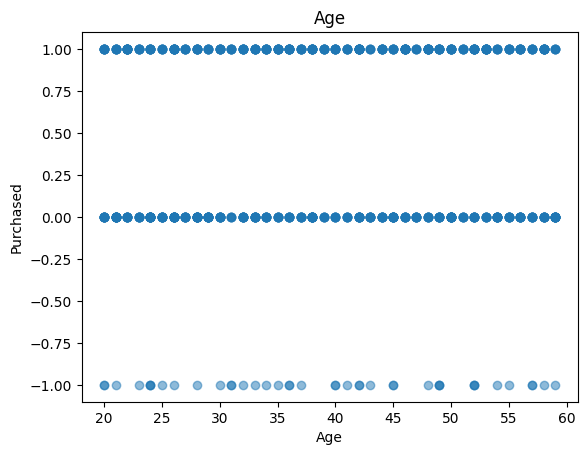

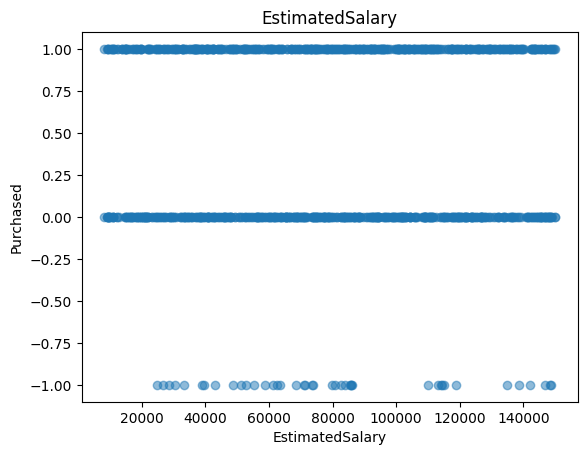

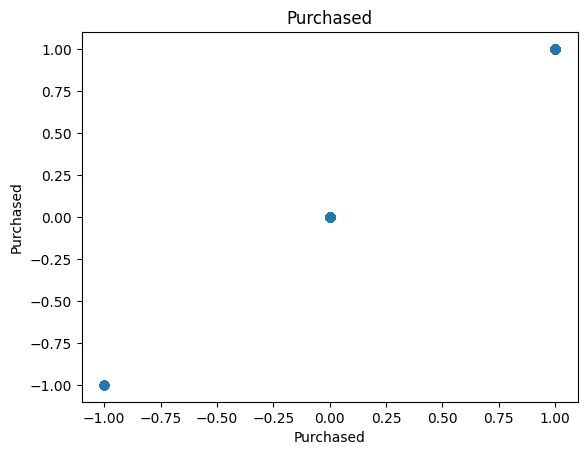

'\n    Insights:\n        The User ID column has absolutely no correlation to purchases and I believe I can safely eliminate this along with\n        the name column. I need to one hot encode the gender to see if there is a correlation between gender and purchase,\n        I could not at this time since this value is non-numerical. Age and estimated seem to be important factors,\n        and I believe Purchased should be split into three different features (purchased, not purchased, and returned).\n\n    Bias:\n        I have my own beliefs as to what would be most important in a customer market, such as a distinct difference between whether\n        a customer bough and returned an item or simply bought and kept an item, though I do not possess any marketing experience.\n'

In [40]:
df.columns=['User ID', 'name', 'Gender', 'Age', 'EstimatedSalary','Purchased']

print(df)
for i in df.columns[1:]:
    X = df[i]
    purchased = df["Purchased"]
    if pd.api.types.is_numeric_dtype(X):
        plt.scatter(X,purchased,alpha=0.5)
        plt.xlabel(i)
        plt.ylabel("Purchased")
        plt.title(i)
        plt.show()

"""
    Insights:
        The User ID column has absolutely no correlation to purchases and I believe I can safely eliminate this along with
        the name column. I need to one hot encode the gender to see if there is a correlation between gender and purchase,
        I could not at this time since this value is non-numerical. Age and estimated seem to be important factors,
        and I believe Purchased should be split into three different features (purchased, not purchased, and returned).

    Bias:
        I have my own beliefs as to what would be most important in a customer market, such as a distinct difference between whether
        a customer bough and returned an item or simply bought and kept an item, though I do not possess any marketing experience.
"""

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [41]:
from sklearn.preprocessing import StandardScaler
"""
    Why:
        I am treating each of the three settings (no purchase, purchased, or returned) as their own separate features to see exactly how
        this changes depending on the customer. This way, we can see which customer market is more likely to optimally purchase and KEEP their clothing,
        so we know exactly what market will be interested and satisfied with the product.

        I am also removing the User ID and name as these have no correlation or consequence in determining the customer market. I am one-hot encoding 
        the male and female genders because the models and standardizing will operate best on numerical data.

    Bias:
        By applying a Standard Scaler, this may alter the data that can effect the overall prediction. Moreover, I have my own bias that the target
        market is the one to buy AND keep clothing, not buy and return, though either scenario generates profit. I also have no experience in
        marketing.


for i, val in df['Purchased'].items():
    if val==0:
        df.at[i, 'No purchase'] = 1
        df.at[i, 'Purchase'] = 0
        df.at[i, 'Return'] = 0
    elif val==1:
        df.at[i, 'Purchase'] = 1
        df.at[i, 'No purchase'] = 0
        df.at[i, 'Return'] = 0
    elif val==-1:
        df.at[i, 'Purchase']=1
        df.at[i, 'Return'] = 1
        df.at[i, 'No purchase']=0
"""
df = df.drop(columns=['name'])


scaler = StandardScaler()
scaler.fit(df)

print(df)

      User ID  Gender  Age  EstimatedSalary  Purchased
0       10000       0   39           147012          1
1       10001       1   24            99556          0
2       10002       1   28           111113          0
3       10003       1   30            78451          1
4       10004       1   38            95148          1
...       ...     ...  ...              ...        ...
996     10996       0   57            67836          0
997     10997       0   26            14656          0
998     10998       1   21            40522          1
999     10999       0   43            74794          1
1000    11000       1   22            83127          0

[1001 rows x 5 columns]


/tmp/ipykernel_1861875/2000105844.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender']=df['Gender'].replace({'Female': 1, 'Male': 0})


# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [58]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score# for classification
import random
import pickle
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

target = 'Purchased'
df['Gender']=df['Gender'].replace({'Female': 1, 'Male': 0})
features = df.columns[df.columns!=target]
print(features)
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=123)
print(X_train.shape,X_test.shape)

model = RandomForestClassifier(
        n_estimators = 1000,
        random_state=123,
        min_samples_leaf=1,
        n_jobs=-1)
model.fit(X_train,y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

tree_to_plot = model.estimators_[0]

"""
plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()
"""
print("Train:", accuracy_score(y_train,y_train_pred))
print("Test:", accuracy_score(y_test,y_test_pred))

feature_importances = model.feature_importances_
features_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)
print("\n",features_df)

pickle.dump(model, open('project3_model.pkl', 'wb'))

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary'], dtype='object')
(800, 4) (201, 4)
Train: 1.0
Test: 0.5223880597014925

            Feature  Importance
3  EstimatedSalary    0.363711
0          User ID    0.355735
2              Age    0.241981
1           Gender    0.038573


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


In [ ]:
"""Initially, I used a Random Forest Classifier on the dataset, yielding 100% accuracy on test data
and 100% accuracy on test data. This felt extremely wrong, and I used a correlation matrix to see what
was causing the data leakage. The way I had it was that there were three separate colums: purchase, no purchase, or
returned. I did this as I thought I heard Mr. Rivero suggest splitting it into three columns. However, this is flagrantly 
wrong. I reverted the three columns back to the original purchased column. When I ran the program, I got 100% train accuracy
and 45% test accuracy. I messed around with the test size parameter in the train_test_split and
found that the test accuracy was the highest, at 49%, when the test size was 20%. I then tried to experiment with
features, including User ID into the datafram. My accuracy jumped to 52%.

# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


In [51]:
"""
    Problem: Given a dataset from a company with multiple features, predict the target audience for sales.

    Summary of findings:
        One of the key findings of the project was that the average salary of the customer was the most
        important feature, with a 36% importance. The second most important was the User ID, which shows
        the sequential order of each purchase. This had an importance of 35%. The third most important
        feature was the Age, with a 26% importance. Overall, the target audience is affluent, middle aged
        persons who are more likely to purchase later models.

    Detail approach:
        Using sci-kit learn and Python, I created a Random Forest classifier model using the dataset provided
        by the company. I was able to predict whether a customer would purchase with 52% accuracy. I saved this
        trained model.


"""

'\n    Problem: Given a dataset from a company with multiple features, predict the target audience for sales.\n\n    Summary of findings:\n        One of the key findings of the project was that the average salary of the customer was the most\n        important feature, with a 36% importance. The second most important was the User ID, which shows\n        the sequential order of each purchase. This had an importance of 35%. The third most important\n        feature was the Age, with a 26% importance. Overall, the target audience is affluent, middle aged\n        persons who are more likely to purchase later models.\n\n    Detail approach:\n        Using sci-kit learn and Python, I created a Random Forest classifier model using the dataset provided\n        by the company. I was able to predict whether a customer would purchase with 52% accuracy. I saved this\n        trained model.\n\n\n'

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [59]:
with open('project3_model.pkl', 'rb') as f:
    loaded_model=pickle.load(f)

def inference(userid, gender, age, estimatedsalary):
    new_features = pd.DataFrame({'User ID':[userid],
                                 'Gender':[gender],
                                 'Age':[age],
                                 'EstimatedSalary':[estimatedsalary]
                                 })

    prediction = loaded_model.predict(new_features.values)
    print("Predicted purchase status: ",prediction)

inference(10004,0,38,100000)

ValueError: could not convert string to float: 'Female'